# Modelo predictivo basado en resnet50

In [13]:
# google drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [14]:
import torch
import pandas as pd
from torchvision.models import resnet50
from PIL import Image
import time

In [15]:
from torchvision.models import resnet50
model = resnet50(weights='IMAGENET1K_V1')
model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [16]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)
model.to(device)

cuda


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [17]:
!ls 'drive/MyDrive/dataset'
PATH= 'drive/MyDrive/dataset'

train  val


In [18]:
from torchvision import transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
from torch.nn import CrossEntropyLoss
from torch.optim import SGD


In [19]:
# preprocessing = transforms.Compose([
#     transforms.Resize(256),
#     transforms.CenterCrop(224),
#     transforms.ToTensor(),
#     transforms.Normalize(
#         mean = [0.485, 0.456, 0.406], std = [0.229, 0.224, 0.225]
# )
# ])

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=(0.485, 0.456, 0.406),
        std=(0.229, 0.224, 0.225)
    )
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=(0.485, 0.456, 0.406),
        std=(0.229, 0.224, 0.225)
    )
])


In [20]:
train_folder = ImageFolder(f"{PATH}/train", transform = train_transform)
val_folder = ImageFolder(f"{PATH}/val", transform = test_transform)

train_loader = DataLoader(train_folder, batch_size = 12, shuffle = True)
val_loader = DataLoader(val_folder, batch_size = 12, shuffle = True)
train_loader, val_loader

(<torch.utils.data.dataloader.DataLoader at 0x7e21ca2694f0>,
 <torch.utils.data.dataloader.DataLoader at 0x7e21ca2693d0>)

In [21]:
for params in model.parameters():
    params.requires_grad = False

In [22]:
model.fc = torch.nn.Linear(2048, 2)
model

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

# Training loop

In [23]:
loss_fn = CrossEntropyLoss()
optimizer = SGD(model.parameters(), lr=0.001) #Optimizador SGD.

In [24]:
inicio = time.perf_counter()

model.to(device)
train_losses = []
val_losses = []
epochs = 5
for epoch in range(epochs):
    model.train()
    train_loss = 0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        y_prob = model(inputs)
        loss = loss_fn(y_prob, labels)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    # Promediar datos de entrenamiento
    train_loss = train_loss / len(train_loader)
    train_losses.append(train_loss)
    model.eval()
    val_loss = 0
    for inputs, labels in val_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        y_prob = model(inputs)
        loss = loss_fn(y_prob, labels)
        val_loss += loss.item()
    # Promediar datos de validación
    val_loss = val_loss / len(val_loader)
    val_losses.append(val_loss)
    print(f"Epoch {epoch}, Train Loss: {train_loss}, Val Loss: {val_loss}")

fin = time.perf_counter()
print(f"Tiempo de ejecución: {fin - inicio}s")

Epoch 0, Train Loss: 0.4671704606153071, Val Loss: 0.3032773807644844
Epoch 1, Train Loss: 0.2821125940536149, Val Loss: 0.1794874332845211
Epoch 2, Train Loss: 0.21561485872371122, Val Loss: 0.12545919348485768
Epoch 3, Train Loss: 0.16424123762408271, Val Loss: 0.09681801195256412
Epoch 4, Train Loss: 0.14131884992821142, Val Loss: 0.09035058575682342
Tiempo de ejecución: 794.653746605s


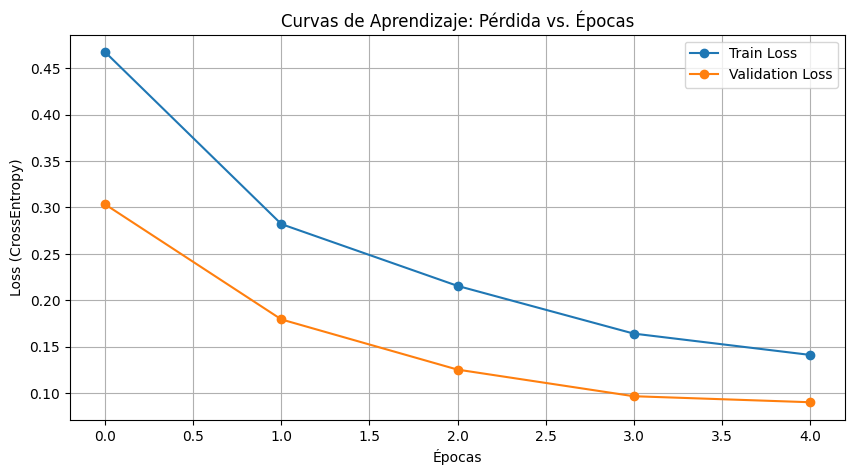

In [25]:
# grafico de perdidas
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss', marker='o')
plt.plot(val_losses, label='Validation Loss', marker='o')
plt.title('Curvas de Aprendizaje: Pérdida vs. Épocas')
plt.xlabel('Épocas')
plt.ylabel('Loss (CrossEntropy)')
plt.legend()
plt.grid(True)
plt.show()

In [26]:
# para métricas
model.eval()

y_true = []
y_pred = []

with torch.no_grad():
    for inputs, labels in val_loader:
        inputs = inputs.to(device)

        outputs = model(inputs)

        _, preds = torch.max(outputs, 1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

--- Reporte de Clasificación ---
                      precision    recall  f1-score   support

      Clase 0 (Sano)       1.00      1.00      1.00       210
Clase 1 (Blanquilla)       1.00      1.00      1.00       170

            accuracy                           1.00       380
           macro avg       1.00      1.00      1.00       380
        weighted avg       1.00      1.00      1.00       380



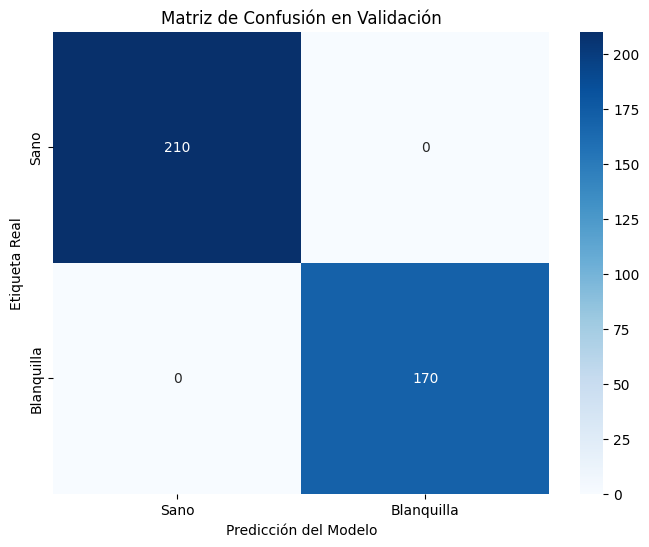

In [27]:
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

print("--- Reporte de Clasificación ---")
print(classification_report(y_true, y_pred, target_names=['Clase 0 (Sano)', 'Clase 1 (Blanquilla)']))

# Matriz de Confusión
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Sano', 'Blanquilla'],
            yticklabels=['Sano', 'Blanquilla'])
plt.xlabel('Predicción del Modelo')
plt.ylabel('Etiqueta Real')
plt.title('Matriz de Confusión en Validación')
plt.show()

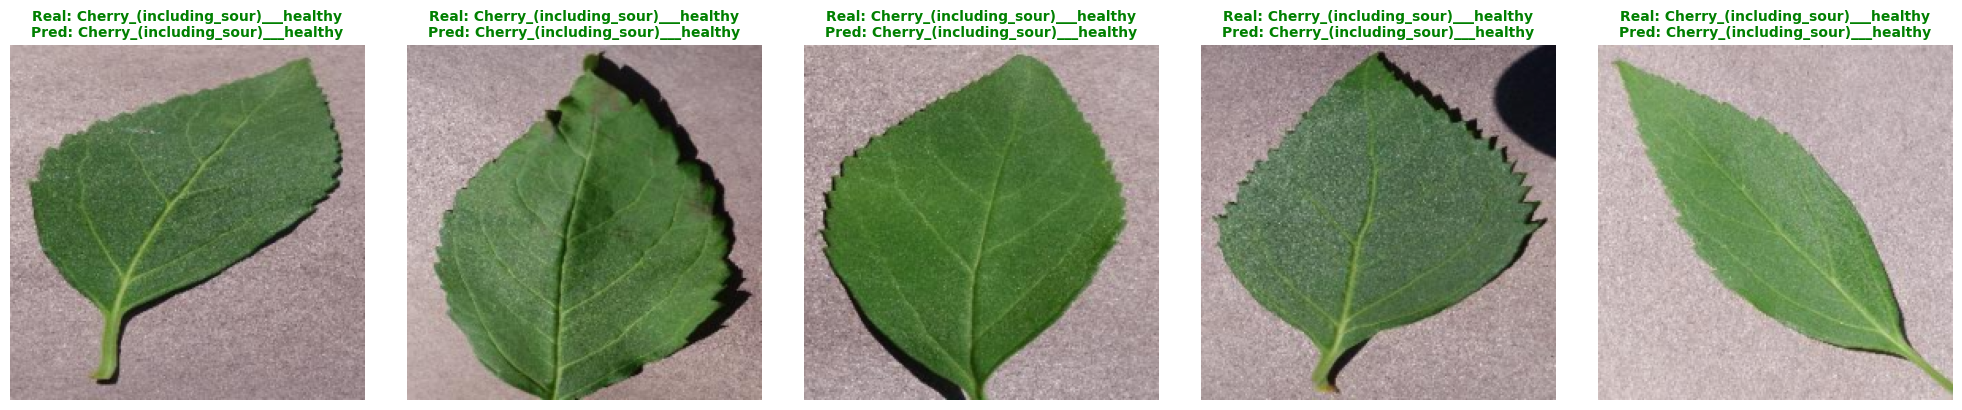

In [28]:
import matplotlib.pyplot as plt
import numpy as np
import random
import torch

model.eval()

# extraer un lote del conjunto de validación
dataiter = iter(val_loader)
inputs, labels = next(dataiter)

# obtener nombres de las clases
class_names = val_folder.classes

# num de imágenes a mostrar
num_images = min(5, len(inputs))

# seleccionar imagenes aleatorias sin repetir
indices = random.sample(range(len(inputs)), num_images)

# Crear figura
fig, axes = plt.subplots(1, num_images, figsize=(4 * num_images, 4))

# Si solo hay una imagen, convertir axes en lista
if num_images == 1:
    axes = [axes]

# params de desnormalización
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])

with torch.no_grad():
    for ax, idx in zip(axes, indices):

        img_tensor = inputs[idx]
        true_label = labels[idx].item()

        # predicción
        img_input = img_tensor.unsqueeze(0).to(device)
        output = model(img_input)
        pred_label = output.argmax(dim=1).item()

        # visualización
        img_display = img_tensor.cpu().numpy().transpose((1, 2, 0))
        img_display = std * img_display + mean
        img_display = np.clip(img_display, 0, 1)

        ax.imshow(img_display)

        color = "green" if true_label == pred_label else "red"

        ax.set_title(
            f"Real: {class_names[true_label]}\nPred: {class_names[pred_label]}",
            color=color,
            fontsize=10,
            fontweight="bold"
        )

        ax.axis("off")

plt.tight_layout()
plt.show()

____
# Guardar pesos

In [29]:
torch.save(model.state_dict(), 'resnet_predictor_DA.pth')